## 0. Loading Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    print(df.info())
    return df

listings = load_data('../Preprocessing/listings_cleaned.csv')

listings.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6993 entries, 0 to 6992
Data columns (total 44 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   id                                           6993 non-null   int64  
 1   listing_url                                  6993 non-null   object 
 2   name                                         6993 non-null   object 
 3   description                                  6812 non-null   object 
 4   picture_url                                  6993 non-null   object 
 5   host_id                                      6993 non-null   int64  
 6   host_response_rate                           6993 non-null   float64
 7   host_acceptance_rate                         6993 non-null   float64
 8   host_is_superhost                            6719 non-null   object 
 9   host_listings_count                          6993 non-null   float64
 10  

,id,listing_url,name,description,picture_url,host_id,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,instant_bookable,calculated_host_listings_count_entire_homes,calculated_host_listings_count_shared_rooms,reviews_per_month,last_review_diff,host_since_diff
0,6624,https://www.airbnb.com/rooms/6624,Venice garden charme and canal view!,I'm thrilled to share my apartment with garden...,https://a0.muscache.com/pictures/65440024/a564...,15016,1.0,0.74,t,9.0,...,4.97,4.93,4.88,4.95,f,1,0,0.54,14.0,5788.0
1,27116,https://www.airbnb.com/rooms/27116,Junior Suite with balcony overlooking canal,"Few steps from Saint Mark square, on a picture...",https://a0.muscache.com/pictures/miso/Hosting-...,116144,1.0,1.00,f,3.0,...,4.90,4.78,4.81,4.94,t,1,0,2.33,842.0,5420.0
2,44527,https://www.airbnb.com/rooms/44527,Luxury Historic Apartment on Calm Sunny Canal,An apartment that blends Gothic style with ini...,https://a0.muscache.com/pictures/d81fb136-a867...,120215,1.0,1.00,t,3.0,...,4.75,4.94,4.94,4.91,f,2,0,0.88,61.0,5413.0
3,47383,https://www.airbnb.com/rooms/47383,Ca' Barba B&B: room n102 (jacuzzi shower),"Ca' Barb B&B, a few steps away from Rialto bri...",https://a0.muscache.com/pictures/550179/3b2f0d...,214390,1.0,1.00,t,4.0,...,4.99,4.99,4.98,4.94,t,1,0,2.32,20.0,5301.0
4,49656,https://www.airbnb.com/rooms/49656,Ca' Foscari Apartment,It’s a lovely quiet newly restored flat within...,https://a0.muscache.com/pictures/41037529-8487...,226598,1.0,1.00,t,3.0,...,4.78,4.95,4.97,4.97,t,2,0,0.87,27.0,5290.0


## 1. Feature Selection

In [3]:
# delete unused columns
delete = ['id', 'listing_url', 'name', 'description', 'picture_url', 'host_id']
listings.drop(columns=delete, inplace=True)

In [4]:
# extract columns with numerical and categorical values
target_clm = 'price'
numerical_columns = listings.select_dtypes(include=['number']).columns.tolist()
numerical_columns.remove(target_clm)
categorical_columns = listings.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numerical columns: ', numerical_columns, '\n')
print('Categorical columns: ', categorical_columns, '\n')

# see if I missed any columns
all_columns = listings.columns.tolist()
assigned_columns = set(numerical_columns + categorical_columns)
unassigned_columns = [col for col in all_columns if col not in assigned_columns]

print('Unassigned columns: ', unassigned_columns)

Numerical columns:  ['host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'maximum_nights_avg_ntm', 'availability_365', 'number_of_reviews', 'number_of_reviews_l30d', 'estimated_occupancy_l365d', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month', 'last_review_diff', 'host_since_diff'] 

Categorical columns:  ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'has_availability', 'instant_bookable'] 

Unassigned columns:  ['price']


In [5]:
# change false feature affiliations
def move_features(numerical_columns, categorical_columns, to_numerical, to_categorical):
    numerical_columns.remove(to_categorical)
    numerical_columns.append(to_numerical)
    
    categorical_columns.remove(to_numerical)
    categorical_columns.append(to_categorical)

to_numerical = []
to_categorical = []

# move_features(numerical_columns, categorical_columns, to_numerical, to_categorical)
    

In [6]:
# for later processing it is important that longer names do not completely contain shorter ones
# therefore checking for collisions in feature names
def column_collisions(from_columns, in_columns):
    collisions = []

    for i, name in enumerate(from_columns):
        for other in in_columns:
            if other != name and other.startswith(name):
                collisions.append((name, other))
    
    print('Colliding collumns: ', collisions)

column_collisions(categorical_columns, categorical_columns + numerical_columns)

Colliding collumns:  []


In [7]:
# rename columns if neccessary
def rename_columns(df, columns_map, columns_list):
    df = df.rename(columns_map)

    for old, new in columns_map.items():
        columns_list[columns_list.index(old)] =  new

# columns_map={'host_id': 'host_ID'}
# rename_columns(list, columns_map, categorical_columns)

## 2. Preprocessing & One-Hot-Encoding
and
## 3. split to training and test data

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

features = numerical_columns + categorical_columns
listings = listings[features + [target_clm]]

listings = pd.get_dummies(listings, 
                        columns=categorical_columns,
                        drop_first=True)


X = listings.drop(columns=[target_clm])
y = np.log1p(listings[target_clm])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# do label encoding
# le = LabelEncoder()

# Encode 

In [9]:
from sklearn.preprocessing import StandardScaler

# scaling the values
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

## 4. train random forest model

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

## 4.5 Evaluate model

In [12]:
import numpy as np
import matplotlib.pyplot as plt

mean squared error:  0.1910668863290283
r^2 score:  0.5404277964803039
mean error: 0.43711198373989735
mean test price: 4.994297755277131


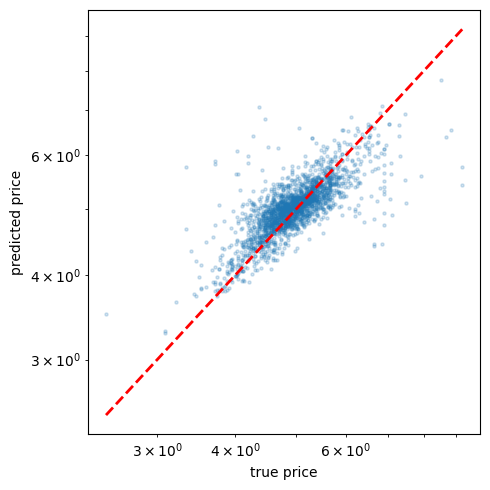

In [13]:
def evaluate_model(model, X_test, y_test):


    # make prediction
    y_pred = model.predict(X_test)
    y_true = y_test

    # evaluate model
    print('mean squared error: ', mean_squared_error(y_true, y_pred))
    print('r^2 score: ', r2_score(y_true, y_pred))
    print('mean error:', np.sqrt(mean_squared_error(y_true, y_pred)))
    print('mean test price:', np.mean(y_true))

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.2, s=5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--r', lw=2)
    plt.xlabel('true price')
    plt.ylabel('predicted price')
    plt.xscale('log')
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

evaluate_model(model, X_test, y_test)

## 5. Visualize most important features

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
# Plot function for feature importances
def plot_feature_importance(importances, feature_names):

    # Aggregate Importance of one-hot encodet features
    grouped_importances = {}
    for name, importance in zip(feature_names, importances):
        found = False
        
        for cat_col in categorical_columns:
            if name.startswith(cat_col + "_"):
                if cat_col in grouped_importances:
                    grouped_importances[cat_col] += importance
                else:
                    grouped_importances[cat_col] = importance
                found = True
                break

        if not found:
            grouped_importances[name] = importance

    # Convert grouped Importances to DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': list(grouped_importances.keys()),
        'Importance': list(grouped_importances.values())
    })

    # Add feature type
    feature_importance_df['Type'] = feature_importance_df['Feature'].apply(
        lambda x: 'Categorical' if x in categorical_columns else 'Numerical'
    )

    # Sort features by importance
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


    unique_types = feature_importance_df['Type'].unique()
    palette = sns.color_palette('viridis', n_colors=len(unique_types))
    type_palette = dict(zip(unique_types, palette))

    # Plot feature Importances
    plt.figure(figsize=(8, 10))
    sns.barplot(
        data=feature_importance_df,
        x='Importance',
        y='Feature',
        hue='Type',
        dodge=False,
        palette=type_palette
    )

    # plt.xscale('log')
    plt.title('Feature Importance in Random Forest Model')
    plt.xlabel(None)
    plt.ylabel(None)
    plt.tight_layout()
    plt.show()

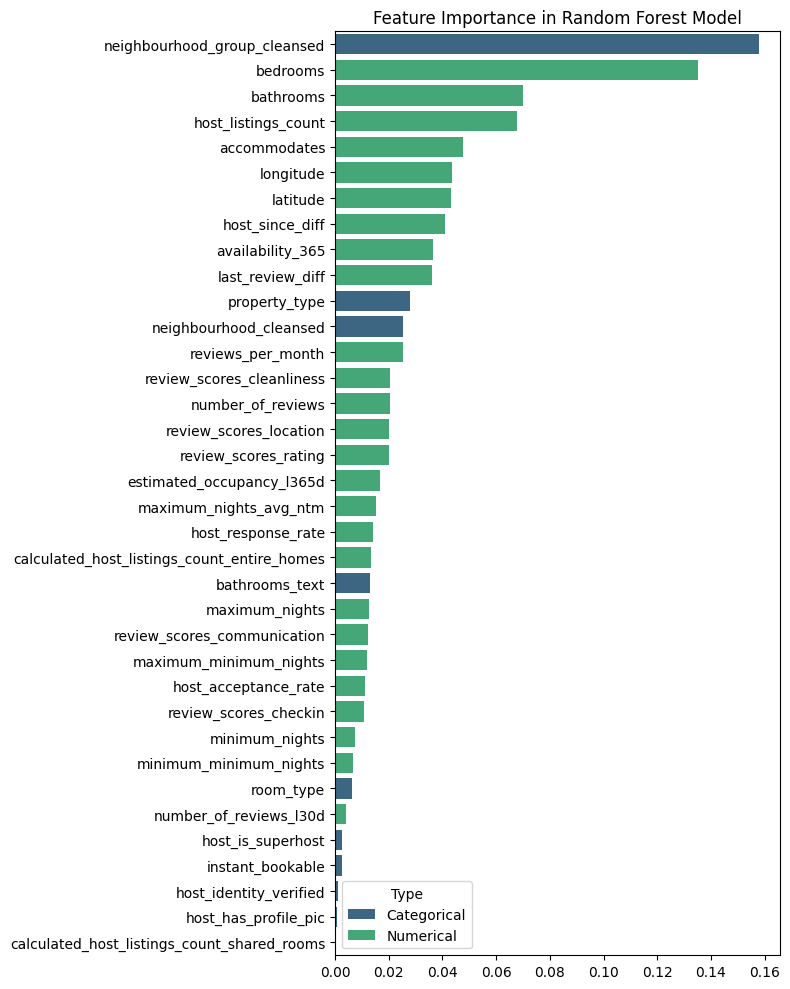

In [16]:
# get feature importances and names
importances = model.feature_importances_
feature_names = X.columns

# Plot importances
plot_feature_importance(importances, feature_names)

## 6. Hyperparameter tuning

In [17]:
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV

In [18]:
# # Initial train test split
# X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # further splitting
# X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)


# defining parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],         # Number of tree-estimators
    'max_depth': [5, 10, 25],        # max depth of trees
    'min_samples_split': [2, 5],        # minimal samples per split
    'min_samples_leaf': [1, 2, 4, 8],          # minimal samples per leaf
    'max_features': ['sqrt', 'log2']  # maximum number of Features per split
}

In [19]:
# cross validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)


# # random Search
# grid_search = RandomizedSearchCV(
#     estimator = RandomForestRegressor(random_state=42),
#     param_distributions = param_grid,
#     scoring = 'neg_root_mean_squared_error',
#     cv = cv,
#     n_jobs = -1,
#     verbose = 2,
#     random_state=42
# )


# Gridsearch
grid_search = GridSearchCV(
    estimator = RandomForestRegressor(random_state=42),
    param_grid = param_grid,
    scoring = 'neg_root_mean_squared_error',
    cv = cv,
    n_jobs = -1,
    verbose = 2 
)

grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 144 candidates, totalling 1440 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


Best found parameter combination:
{'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200} 

mean squared error:  0.17174103349711137
r^2 score:  0.5869121713581503
mean error: 0.4144164976169643
mean test price: 4.994297755277131


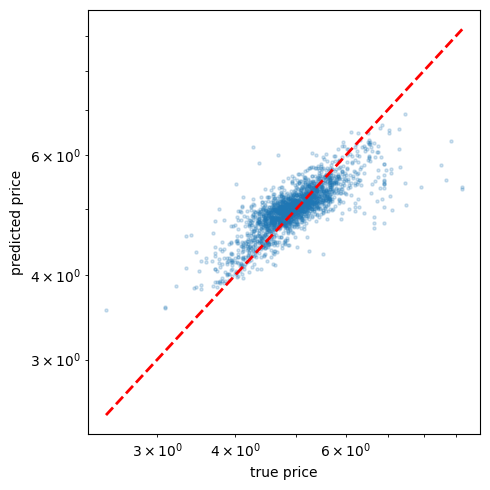

In [ ]:
# Return best parameters
print('Best found parameter combination:')
print(grid_search.best_params_, '\n')

best_model = grid_search.best_estimator_

evaluate_model(best_model, X_test, y_test)

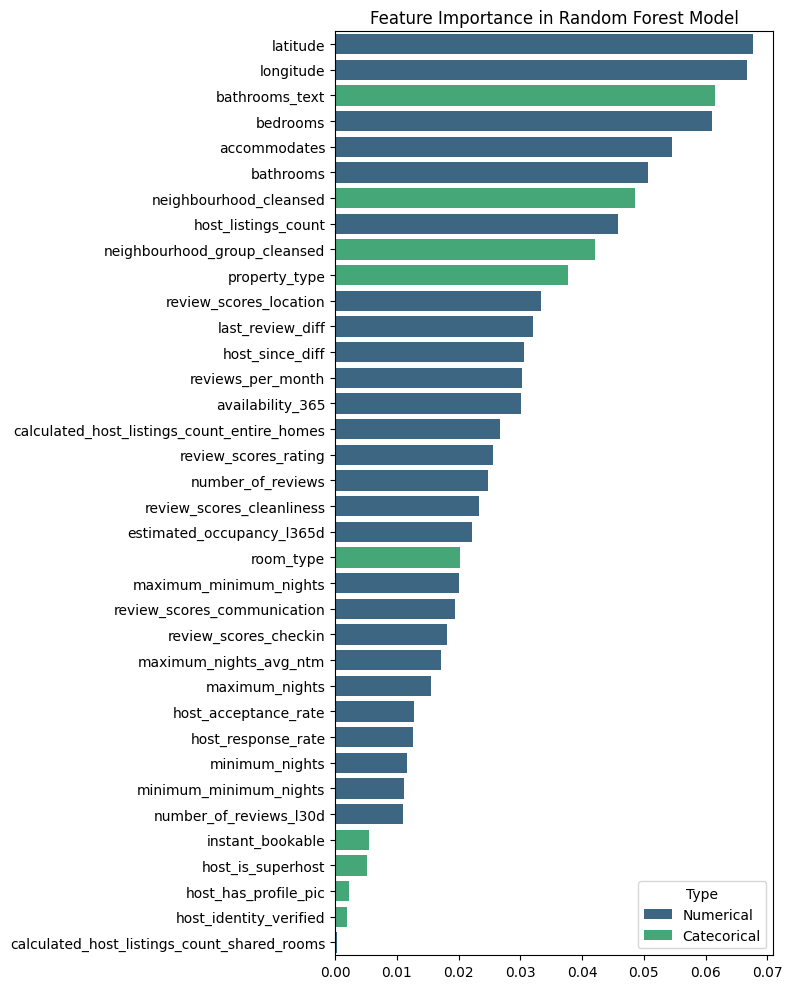

In [ ]:
# get feature importances and names
importances = best_model.feature_importances_
feature_names = X.columns

# Plot importances
plot_feature_importance(importances, feature_names)

## Todo:
- Textdaten mit TF-IDF oder Embeddings verwenden
- Präsentation & Reporting vorbereiten
- Kombiniere mit calendar.csv → z. B. durchschnittliche Verfügbarkeit
- Berechne Distanz zum Zentrum oder zu Sehenswürdigkeiten
- Vergleiche mit Linearer Regression, Gradient Boosting etc.
- optimale parameter nochmal anschauen, ob range genug ist
- auf gpu programmieren